In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df= pd.read_csv("/content/customer_segmentation_data.csv")

In [ ]:
df.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [ ]:
df.shape

(53503, 20)

In [ ]:
df.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Marital Status,0
Education Level,0
Geographic Information,0
Occupation,0
Income Level,0
Behavioral Data,0
Purchase History,0


In [ ]:
df.describe()

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


**Exploratory Data Analysis**

**Univariate Data Analysis**

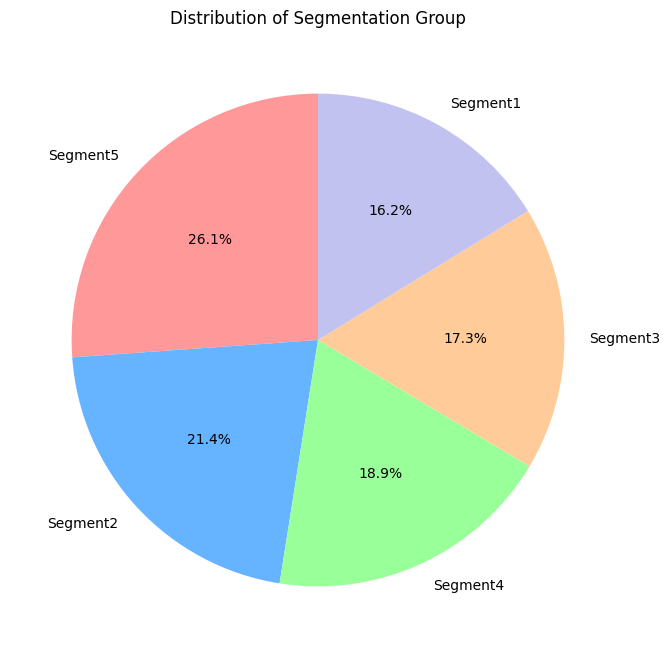

In [ ]:
# Count the occurrences of each class in the 'Segmentation Group' column
segmentation_counts = df['Segmentation Group'].value_counts()

# Plot a pie chart
plt.figure(figsize=(8, 8))
segmentation_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.title('Distribution of Segmentation Group')
plt.ylabel('')
plt.show()

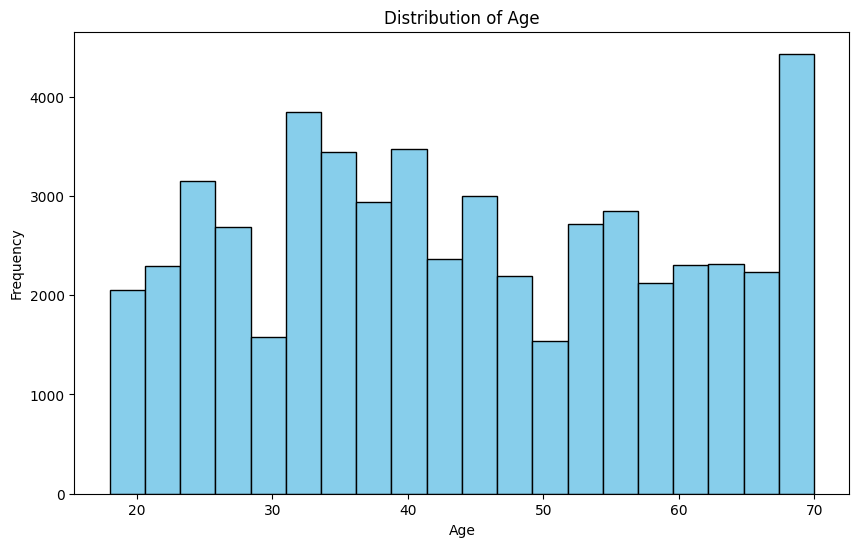

In [ ]:
# Plot histogram for 'Age'
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')

# Add title and labels
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Show the plot
plt.show()

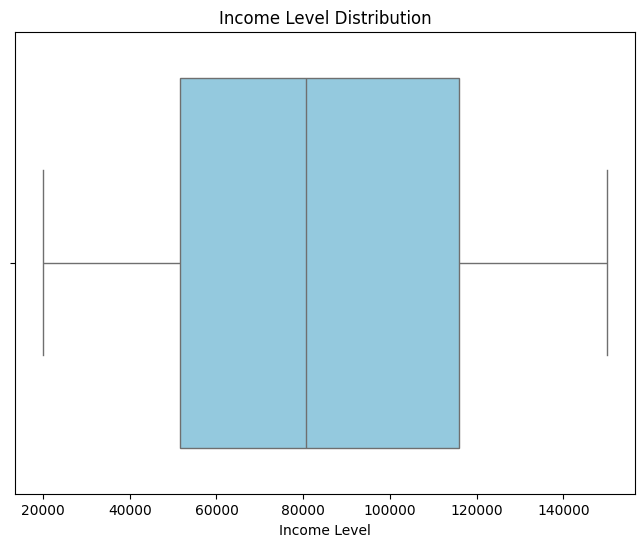

In [ ]:
# Create a box plot for Income Level
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Income Level'], color='skyblue')

# Add title and labels
plt.title('Income Level Distribution')
plt.xlabel('Income Level')

# Show the plot
plt.show()

/tmp/ipython-input-1609806238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


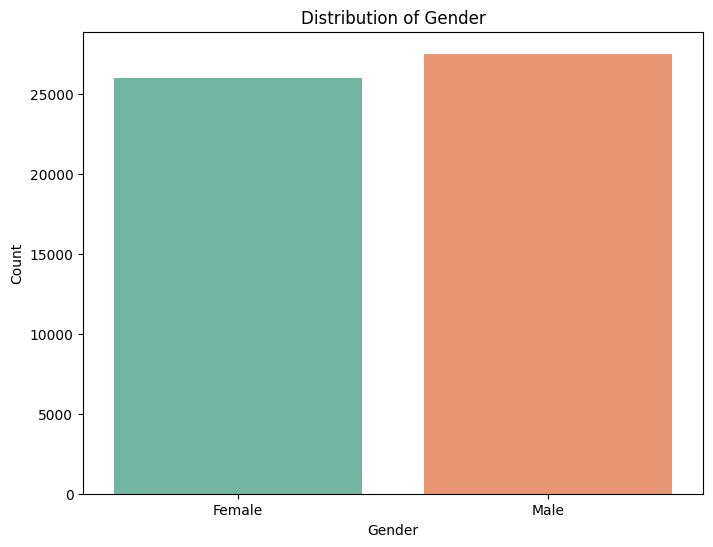

In [ ]:
# Create a bar plot for 'Gender'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', palette='Set2')

# Add title and labels
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Show the plot
plt.show()

/tmp/ipython-input-1088142879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Marital Status', palette='Set3')


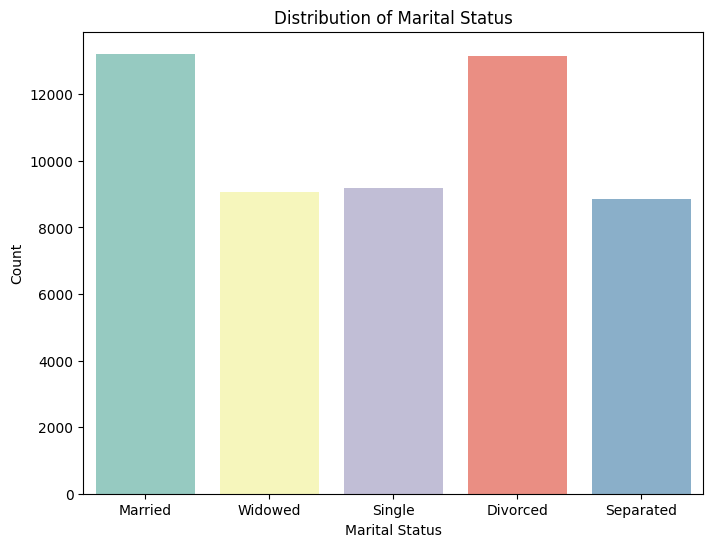

In [ ]:

# Create a bar plot for 'Marital Status'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Marital Status', palette='Set3')

# Add title and labels
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')

# Show the plot
plt.show()

/tmp/ipython-input-2345814036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Education Level', palette='Pastel1')


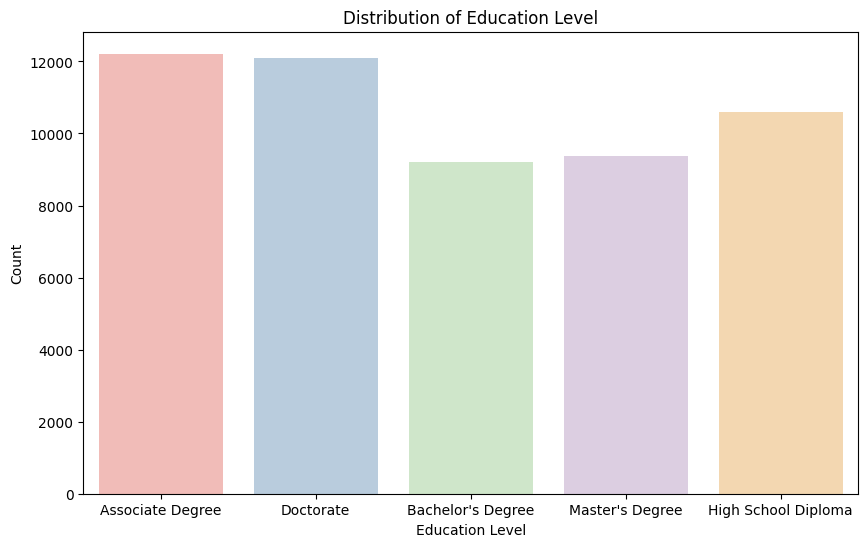

In [ ]:
# Create a bar plot for 'Education Level'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Education Level', palette='Pastel1')

# Add title and labels
plt.title('Distribution of Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')

# Show the plot
plt.show()

/tmp/ipython-input-2148185741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Occupation', palette='Set2')


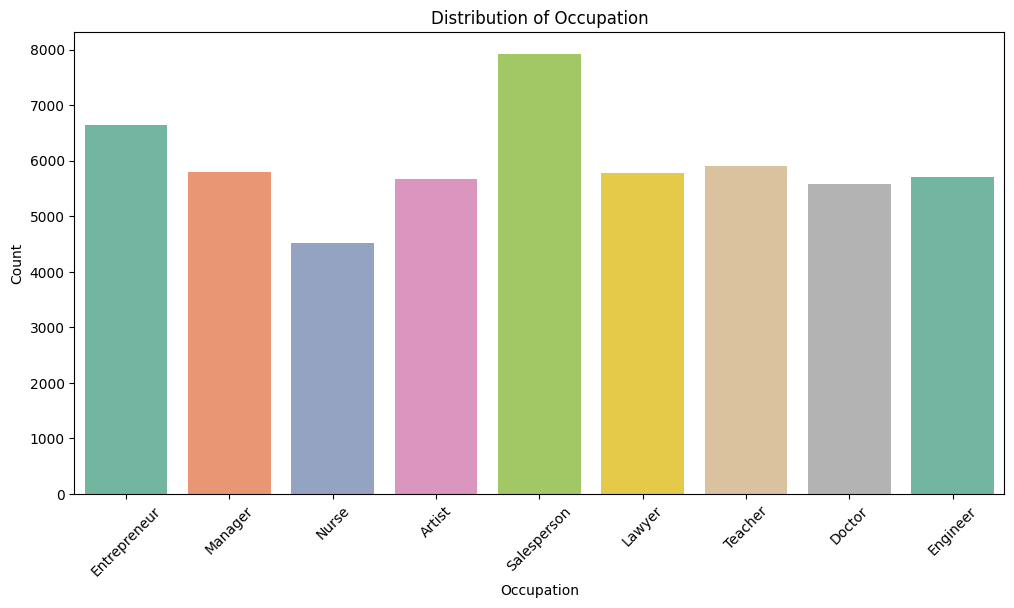

In [ ]:
# Create a bar plot for 'Occupation'
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Occupation', palette='Set2')

# Add title and labels
plt.title('Distribution of Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')

# Rotate x-axis labels for better readability if there are many occupations
plt.xticks(rotation=45)

# Show the plot
plt.show()

**Bivariate Data Analysis**

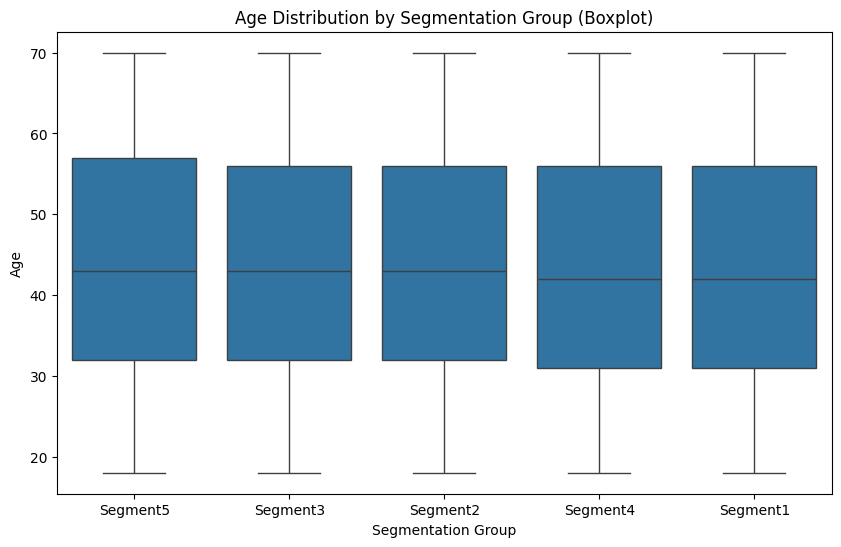

In [ ]:
plt.figure(figsize=(10, 6))

# Create a boxplot for Age distribution by Segmentation Group
sns.boxplot(data=df, x='Segmentation Group', y='Age')

# Title and labels
plt.title('Age Distribution by Segmentation Group (Boxplot)')
plt.xlabel('Segmentation Group')
plt.ylabel('Age')

# Show plot
plt.show()

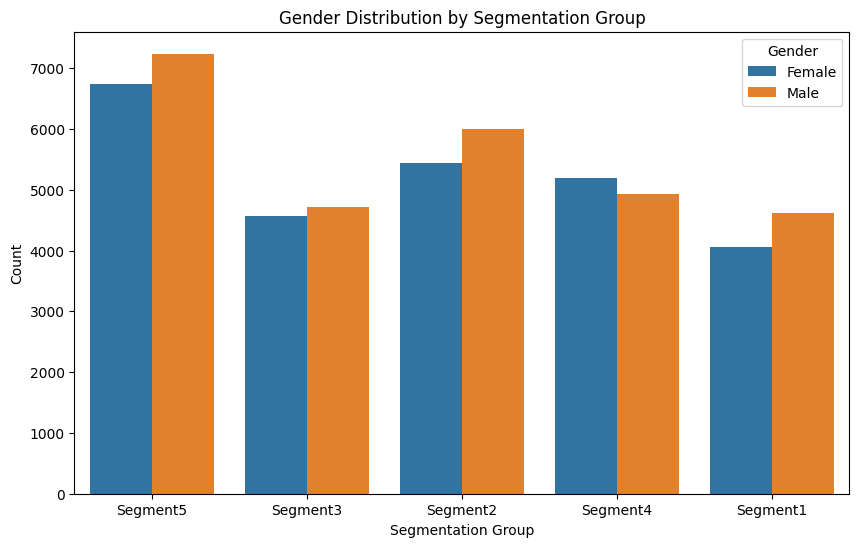

In [ ]:
# Assuming 'data' is already loaded
plt.figure(figsize=(10, 6))

# Create a countplot for Gender by Segmentation Group
sns.countplot(data=df, x='Segmentation Group', hue='Gender')

# Title and labels
plt.title('Gender Distribution by Segmentation Group')
plt.xlabel('Segmentation Group')
plt.ylabel('Count')

# Show plot
plt.show()

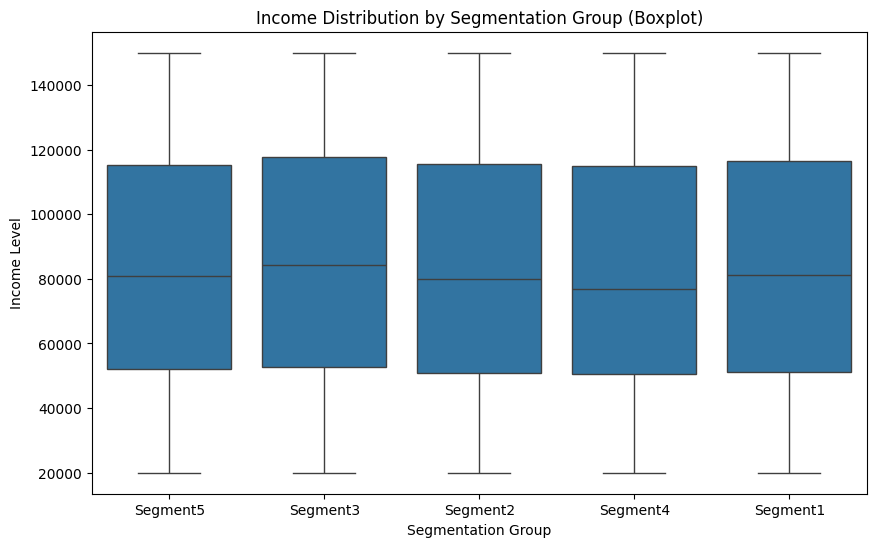

In [ ]:
# Assuming 'data' is already loaded
plt.figure(figsize=(10, 6))

# Create a boxplot for Income Level by Segmentation Group
sns.boxplot(data=df, x='Segmentation Group', y='Income Level')

# Title and labels
plt.title('Income Distribution by Segmentation Group (Boxplot)')
plt.xlabel('Segmentation Group')
plt.ylabel('Income Level')

# Show plot
plt.show()

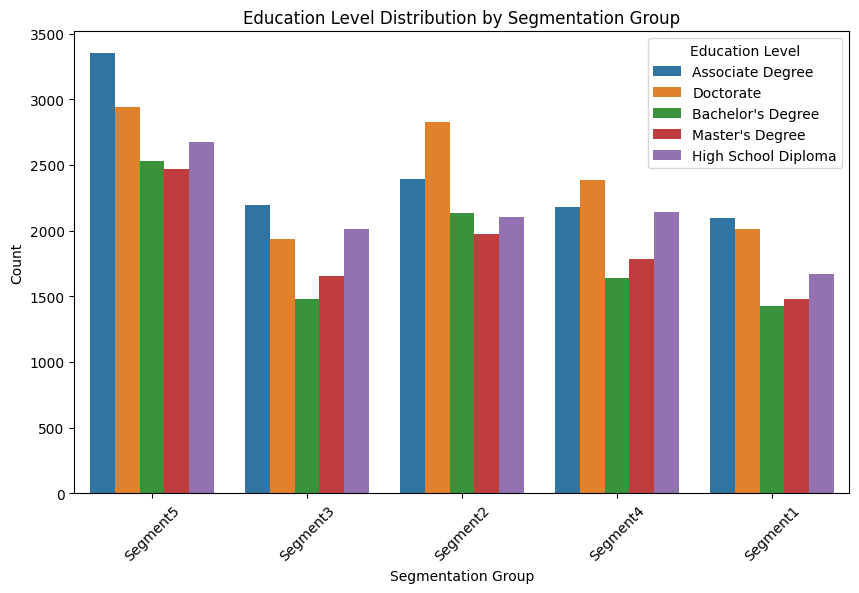

In [ ]:
# Assuming 'data' is already loaded
plt.figure(figsize=(10, 6))

# Create a countplot for Education Level by Segmentation Group
sns.countplot(data=df, x='Segmentation Group', hue='Education Level')

# Title and labels
plt.title('Education Level Distribution by Segmentation Group')
plt.xlabel('Segmentation Group')
plt.ylabel('Count')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.show()

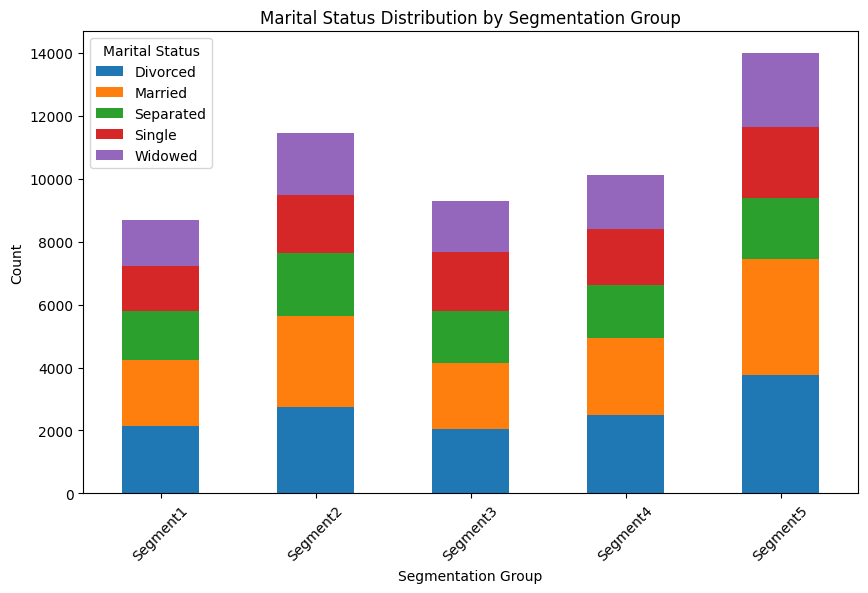

In [ ]:
# Create a pivot table for marital status distribution across segmentation groups
marital_pivot = pd.crosstab(df['Segmentation Group'], df['Marital Status'])

# Plot the stacked bar plot
marital_pivot.plot(kind='bar', stacked=True, figsize=(10, 6))

# Title and labels
plt.title('Marital Status Distribution by Segmentation Group')
plt.xlabel('Segmentation Group')
plt.ylabel('Count')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.show()

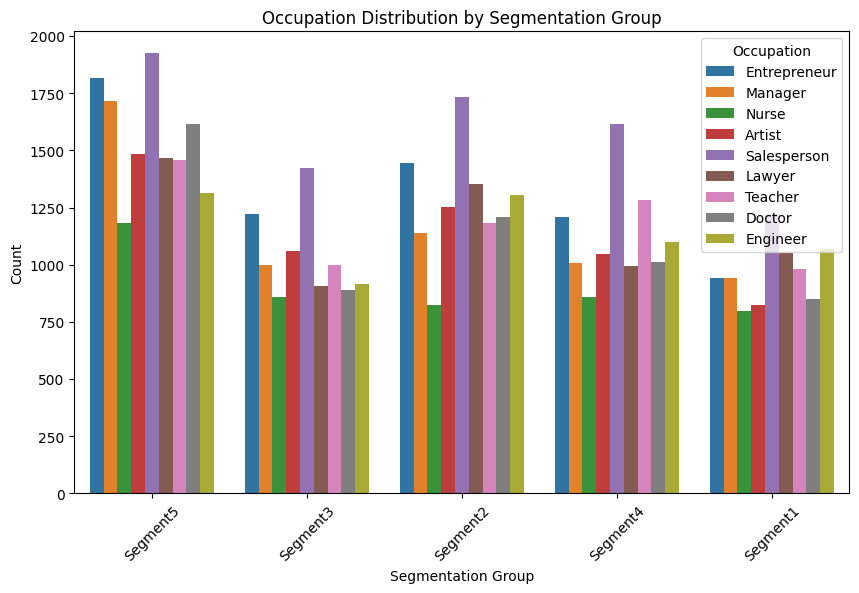

In [ ]:
# Assuming 'data' is already loaded
plt.figure(figsize=(10, 6))

# Create a countplot for Occupation by Segmentation Group
sns.countplot(data=df, x='Segmentation Group', hue='Occupation')

# Title and labels
plt.title('Occupation Distribution by Segmentation Group')
plt.xlabel('Segmentation Group')
plt.ylabel('Count')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.show()

**Data Preprocessing**

In [ ]:
df= df.dropna(subset=['Purchase History'])

In [ ]:
df['Purchase History']

,Purchase History
0,2018-04-10
1,2018-11-06
2,2021-06-05
3,2018-09-02
4,2018-09-10
...,...
53488,2022-07-02
53490,2021-05-12
53494,2019-02-12
53498,2019-01-01


In [ ]:
# Convert 'Purchase History' to datetime format if it's not already
df['Purchase History'] = pd.to_datetime(df['Purchase History'], errors='coerce')

# Extract day, month, and year from the 'Purchase History' column
df['Purchase Day'] = df['Purchase History'].dt.day.astype(int)
df['Purchase Month'] = df['Purchase History'].dt.month.astype(int)
df['Purchase Year'] = df['Purchase History'].dt.year.astype(int)

# Show the first few rows after extracting date component
df[['Purchase History', 'Purchase Day', 'Purchase Month', 'Purchase Year']].head()

,Purchase History,Purchase Day,Purchase Month,Purchase Year
0,2018-04-10,10,4,2018
1,2018-11-06,6,11,2018
2,2021-06-05,5,6,2021
3,2018-09-02,2,9,2018
4,2018-09-10,10,9,2018


In [ ]:
df= df.drop('Purchase History', axis=1)

In [ ]:
# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# List of categorical columns to encode
categorical_columns = ['Gender', 'Marital Status', 'Education Level', 'Occupation',"Behavioral Data","Interactions with Customer Service","Insurance Products Owned",
                       "Policy Type","Customer Preferences","Preferred Communication Channel","Preferred Contact Time","Preferred Language", "Geographic Information",'Segmentation Group']

# Apply label encoding to each categorical column
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Show the first few rows after encoding to confirm
df.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Interactions with Customer Service,...,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Purchase Day,Purchase Month,Purchase Year
0,84966,23,0,1,0,22,3,70541,4,4,...,2749,2,0,1,0,0,4,10,4,2018
1,95568,26,1,4,2,10,5,54168,4,0,...,1966,2,2,1,3,1,4,6,11,2018
2,10544,29,0,3,0,27,3,73899,4,1,...,4413,2,0,2,2,2,2,5,6,2021
3,77033,20,1,0,1,28,3,63381,4,0,...,4342,1,4,1,1,1,2,2,9,2018
4,88160,25,0,2,1,34,5,38794,0,0,...,1276,1,0,4,4,0,1,10,9,2018


In [ ]:
continuous_columns = ['Age', 'Income Level',"Coverage Amount", "Premium Amount"]

# Initialize the scaler (StandardScaler or MinMaxScaler)
scaler = StandardScaler()

# Scale the continuous variables
df[continuous_columns] = scaler.fit_transform(df[continuous_columns])

# Check the scaled data
df[continuous_columns].head()

,Age,Income Level,Coverage Amount,Premium Amount
0,-1.390180,-0.335202,-0.467516,-0.218153
1,-1.191803,-0.780380,1.072092,-0.829616
2,-0.993427,-0.243899,1.048605,1.081304
3,-1.588556,-0.529881,1.100302,1.025859
4,-1.257929,-1.198395,-0.467877,-1.368453


In [ ]:
X = df[['Age', 'Gender', 'Income Level', 'Education Level', 'Marital Status', 'Occupation']]
y = df['Segmentation Group']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**AdaBoost Algorithm**

In [ ]:
base_estimator = DecisionTreeClassifier(max_depth=1)

In [ ]:
ada_boost = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)

In [ ]:
ada_boost.fit(X_train, y_train)
y_pred = ada_boost.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.25
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       763
           1       0.18      0.01      0.01       999
           2       0.00      0.00      0.00       752
           3       0.26      0.03      0.05       869
           4       0.26      0.97      0.40      1156

    accuracy                           0.25      4539
   macro avg       0.14      0.20      0.09      4539
weighted avg       0.16      0.25      0.12      4539

Confusion Matrix:
[[   0    7    0   21  735]
 [   0    7    0   12  980]
 [   0    8    0   15  729]
 [   0    5    0   23  841]
 [   0   11    0   18 1127]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
param_grid_ada = {
    'n_estimators': [50, 100, 150],  # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 1],  # Learning rate
    'estimator__max_depth': [1, 3, 5]  # Max depth for base estimator
}

In [ ]:
grid_search_ada = GridSearchCV(estimator=ada_boost, param_grid=param_grid_ada, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_ada.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 3, 5],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=1)

In [ ]:
print("Best Hyperparameters for AdaBoost:", grid_search_ada.best_params_)
print("Best Cross-Validation Accuracy for AdaBoost:", grid_search_ada.best_score_)

Best Hyperparameters for AdaBoost: {'estimator__max_depth': 1, 'learning_rate': 1, 'n_estimators': 50}
Best Cross-Validation Accuracy for AdaBoost: 0.26795551522195676


**Support Vector Machine**

In [ ]:
svm_model = SVC(kernel='poly', random_state=42)

In [ ]:
svm_model.fit(X_train, y_train)

SVC(kernel='poly', random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.25
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       763
           1       0.00      0.00      0.00       999
           2       0.00      0.00      0.00       752
           3       0.00      0.00      0.00       869
           4       0.25      1.00      0.41      1156

    accuracy                           0.25      4539
   macro avg       0.05      0.20      0.08      4539
weighted avg       0.06      0.25      0.10      4539

Confusion Matrix:
[[   0    0    0    0  763]
 [   0    0    0    0  999]
 [   0    0    0    0  752]
 [   0    0    0    0  869]
 [   0    0    0    0 1156]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernels
    'gamma': ['scale', 'auto', 0.1, 1]  # Gamma values for rbf and poly kernels
}

In [ ]:
grid_search_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:
print("Best Hyperparameters for SVM:", grid_search_svm.best_params_)
print("Best Cross-Validation Accuracy for SVM:", grid_search_svm.best_score_)

**CNN**

In [ ]:
# Step 4: Build the Neural Network Model
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))

# Second hidden layer
model.add(Dense(32, activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Output layer with a softmax activation function (multi-class classification)
model.add(Dense(len(y.unique()), activation='softmax'))  # Number of classes in target variable

# Step 5: Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Step 6: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 7: Evaluate the model
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)  # Convert probabilities to class labels


Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2472 - loss: 1.6326 - val_accuracy: 0.2512 - val_loss: 1.5951
Epoch 2/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2601 - loss: 1.5930 - val_accuracy: 0.2523 - val_loss: 1.5977
Epoch 3/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2666 - loss: 1.5895 - val_accuracy: 0.2518 - val_loss: 1.5978
Epoch 4/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2582 - loss: 1.5901 - val_accuracy: 0.2525 - val_loss: 1.5966
Epoch 5/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2647 - loss: 1.5891 - val_accuracy: 0.2505 - val_loss: 1.5967
Epoch 6/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2668 - loss: 1.5875 - val_accuracy: 0.2485 - val_loss: 1.5967
Epoch 7/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2679 - loss: 1.5854 - val_accuracy: 0.2432 - val_loss: 1.5965
Epoch 8/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2646 - loss: 1.5863 - val_accuracy: 0.

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.24
Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.01      0.01       763
           1       0.20      0.15      0.17       999
           2       0.32      0.02      0.03       752
           3       0.13      0.01      0.02       869
           4       0.25      0.80      0.38      1156

    accuracy                           0.24      4539
   macro avg       0.21      0.20      0.12      4539
weighted avg       0.21      0.24      0.15      4539

Confusion Matrix:
[[  5 110   5  15 628]
 [  2 148   5   9 835]
 [  8 118  13  13 600]
 [  7 147   6   7 702]
 [  9 202  12  10 923]]
